In [1]:
# --- figure routing (restructured to match lecture 06) -------------------
import os
try:
    BASE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE = os.getcwd()          # notebook is run from its own folder
CODE_ROOT = os.path.join(BASE, "..")
FIGROOT = os.path.join(BASE, "02_figures")

# Each figure is saved as PDF into FIGROOT/<slide-folder>/, named by the slide
# it appears on in the exported lecture PDF. Edit numbers/labels here to taste.
SLIDE_MAP = [
    ('scatter_confidence', '33_confidence_band'),
    ('scatter_histogram', '27_regression_metrics'),
    ('scatter_train_test_split', '31_train_test_split'),
    ('scatter_', '07_feature_target_relation'),
    ('surface_', '09_function_surface'),
    ('heatmap_', '20_joint_distribution'),
]

def _folder_for(name):
    """Return the per-slide subfolder for a figure file name."""
    for pat, folder in SLIDE_MAP:
        if pat in name:
            return folder
    return "_unsorted"

def figpath(name):
    """Resolve a figure name to FIGROOT/<slide-folder>/<name>, creating the folder."""
    if not (name.endswith(".pdf") or name.endswith(".gif")):
        name = name + ".pdf"
    folder = os.path.join(FIGROOT, _folder_for(name))
    os.makedirs(folder, exist_ok=True)
    return os.path.join(folder, name)
# ------------------------------------------------------------------------

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use(os.path.join(BASE,"..", "configs", "visualisations.mplstyle"))

directory = "data"
file_name = "1900_2021_DISASTERS.csv"
file_path = os.path.join(BASE,"..", directory, file_name)

df = pd.read_csv(file_path)

figure_path = os.path.join(BASE, '02_figures')
if not os.path.exists(figure_path):
    os.makedirs(figure_path)

df = df.convert_dtypes()
df['Total Damages (US$)'] = df['Total Damages (\'000 US$)'] * 1000

df['date'] = pd.to_datetime(
    dict(
        year=df['Start Year'],
        month=df['Start Month'].fillna(1).astype(int),
        day=df['Start Day'].fillna(1).astype(int)
    ),
    errors='coerce'
)

df['Disaster Type'] = df['Disaster Type'].astype('category')
df.dtypes

Year                                   Int64
Seq                                    Int64
Glide                         string[python]
Disaster Group                string[python]
Disaster Subgroup             string[python]
Disaster Type                       category
Disaster Subtype              string[python]
Disaster Subsubtype           string[python]
Event Name                    string[python]
Country                       string[python]
ISO                           string[python]
Region                        string[python]
Continent                     string[python]
Location                      string[python]
Origin                        string[python]
Associated Dis                string[python]
Associated Dis2               string[python]
OFDA Response                 string[python]
Appeal                        string[python]
Declaration                   string[python]
Aid Contribution                       Int64
Dis Mag Value                          Int64
Dis Mag Sc

# VL 2: Statistical Learning

In [2]:
def _plot_scatter(df, x_axis, y_axis, fit_polyfit, n=2):
    mask = (df[x_axis] > 0) & (df[y_axis] > 0)
    x = np.log10(df.loc[mask, x_axis])
    y = np.log10(df.loc[mask, y_axis])

    plt.scatter(x, y,s=20,marker='o', alpha=1,edgecolors='w', linewidth=0.5)

    # add a fitted line of degree n
    if fit_polyfit:
        coefficients = np.polyfit(x, y, n)
        poly = np.poly1d(coefficients)
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = poly(x_fit)
        plt.plot(x_fit, y_fit, color='red', linewidth=2, label=f'Polyfit ${n}^{{nd}}$ Degree')
        

    plt.xticks(ticks=np.log10([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]), labels=['$10^0$', '$10^1$', '$10^2$', '$10^3$', '$10^4$', '$10^5$', '$10^6$'])
    plt.yticks(ticks=np.log10([1e4, 1e6, 1e8, 1e10, 1e12]), labels=['$10^4$', '$10^6$', '$10^8$', '$10^{10}$', '$10^{12}$'])
    plt.legend()

    plt.xlabel(f'{x_axis}')
    plt.ylabel(f'{y_axis}')
    plt.title(f'Scatterplot of {x_axis} vs. {y_axis}')
    plt.savefig(figpath(f'scatter_{x_axis}_{y_axis}_fit{n}.pdf'), bbox_inches='tight')
    plt.show()


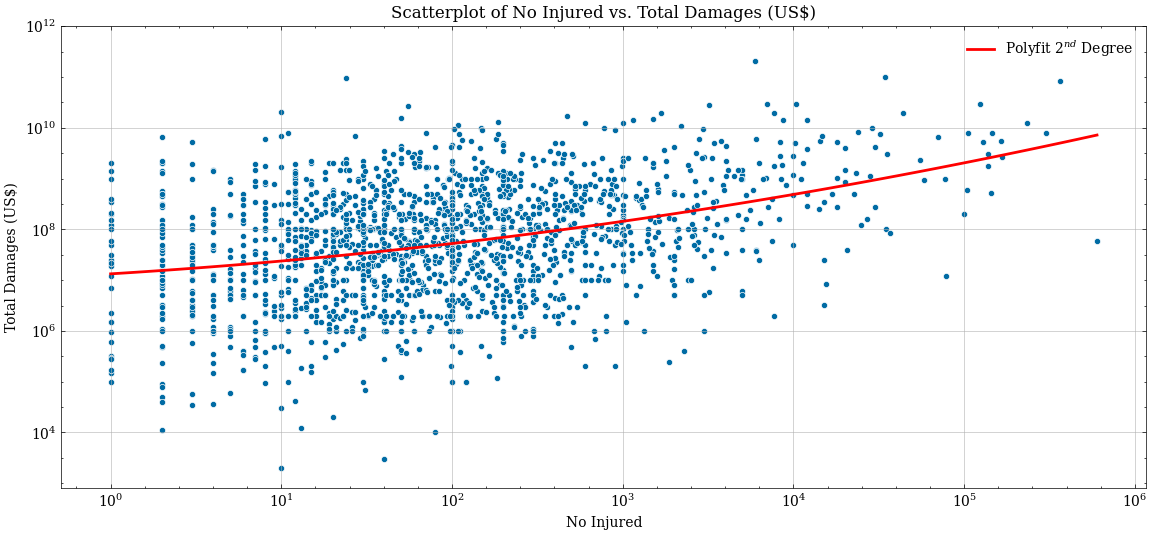

In [3]:
x_axis = 'No Injured'
y_axis = 'Total Damages (US$)'
fit_polyfit = True

_plot_scatter(df, x_axis, y_axis, fit_polyfit)

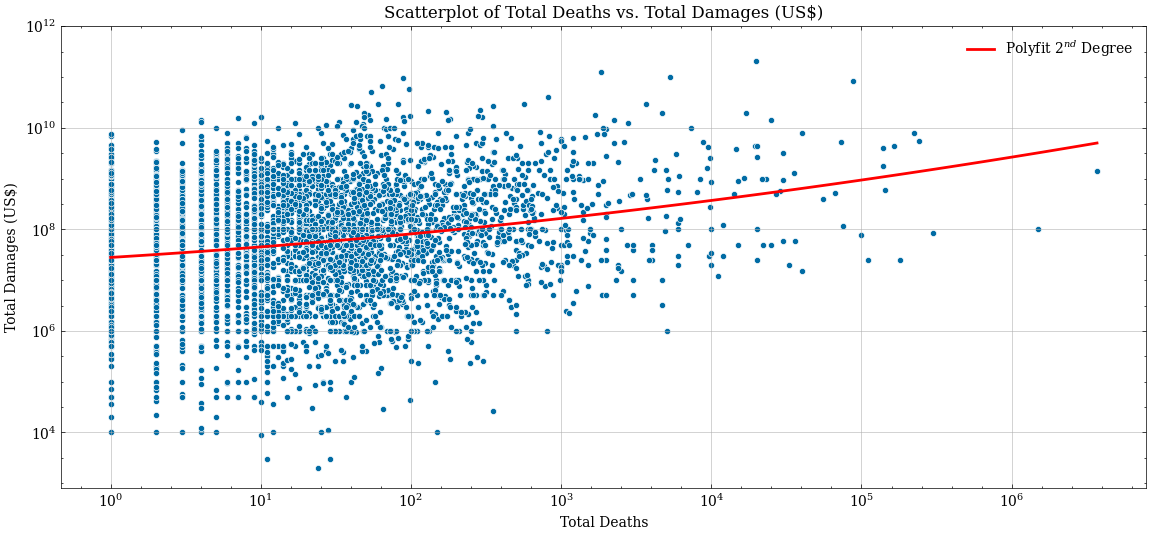

In [4]:
x_axis = 'Total Deaths'
y_axis = 'Total Damages (US$)'
fit_polyfit = True

_plot_scatter(df, x_axis=x_axis, y_axis=y_axis, fit_polyfit=fit_polyfit)

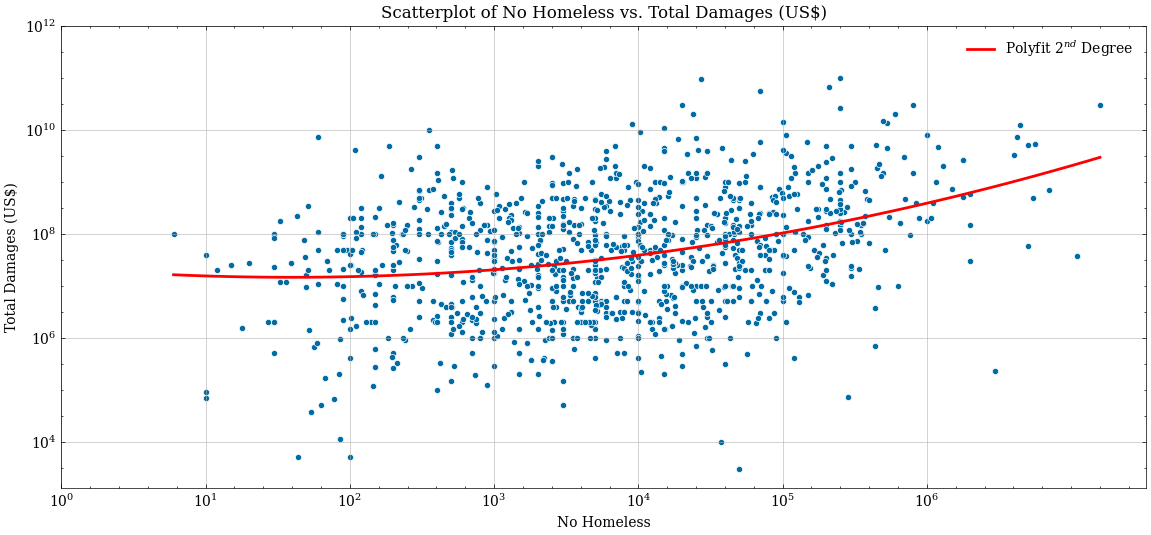

In [5]:
x_axis = 'No Homeless'
y_axis = 'Total Damages (US$)'
fit_polyfit = True

_plot_scatter(df, x_axis=x_axis, y_axis=y_axis, fit_polyfit=fit_polyfit)

### Slide 7

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def _plot_3D_surface(elev=20, azim=-45, grid_size=100):
    x_axis = 'No Injured'
    y_axis = 'Total Deaths'
    z_axis = 'Total Damages (US$)'

    subset_df = df[
        (df[x_axis] > 0) &
        (df[y_axis] > 0) &
        (df[z_axis] > 0)
    ]

    x = np.log10(subset_df[x_axis])
    y = np.log10(subset_df[y_axis])
    z = np.log10(subset_df[z_axis])

    # Create grid
    xi = np.linspace(x.min(), x.max(), grid_size)
    yi = np.linspace(y.min(), y.max(), grid_size)
    X, Y = np.meshgrid(xi, yi)

    # Interpolate z values
    Z = griddata((x, y), z, (X, Y), method='linear')
    
    # Plot surface
    fig = plt.figure(figsize=(15, 15))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='coolwarm')
    ax.set_xticks(ticks=np.log10([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]), labels=['$10^0$', '$10^1$', '$10^2$', '$10^3$', '$10^4$', '$10^5$', '$10^6$'])
    ax.set_yticks(ticks=np.log10([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]), labels=['$10^0$', '$10^1$', '$10^2$', '$10^3$', '$10^4$', '$10^5$', '$10^6$'])
    ax.set_zticks(ticks=np.log10([1e4, 1e6,  1e8, 1e10]), labels=[ '$10^4$',  '$10^6$', '$10^8$', '$10^{10}$'])
    ax.set_zlim(4, 11)
    ax.set_xlabel(f"{x_axis}")
    ax.set_ylabel(f"{y_axis}")
    ax.set_zlabel(f"{z_axis}")
    ax.view_init(elev=elev, azim=azim, roll=0)
    ax.set_box_aspect(None, zoom=0.8)
    plt.savefig(figpath(f'surface_{x_axis}_{y_axis}_{z_axis}_grid_{grid_size}.pdf'), bbox_inches='tight')
    plt.show()

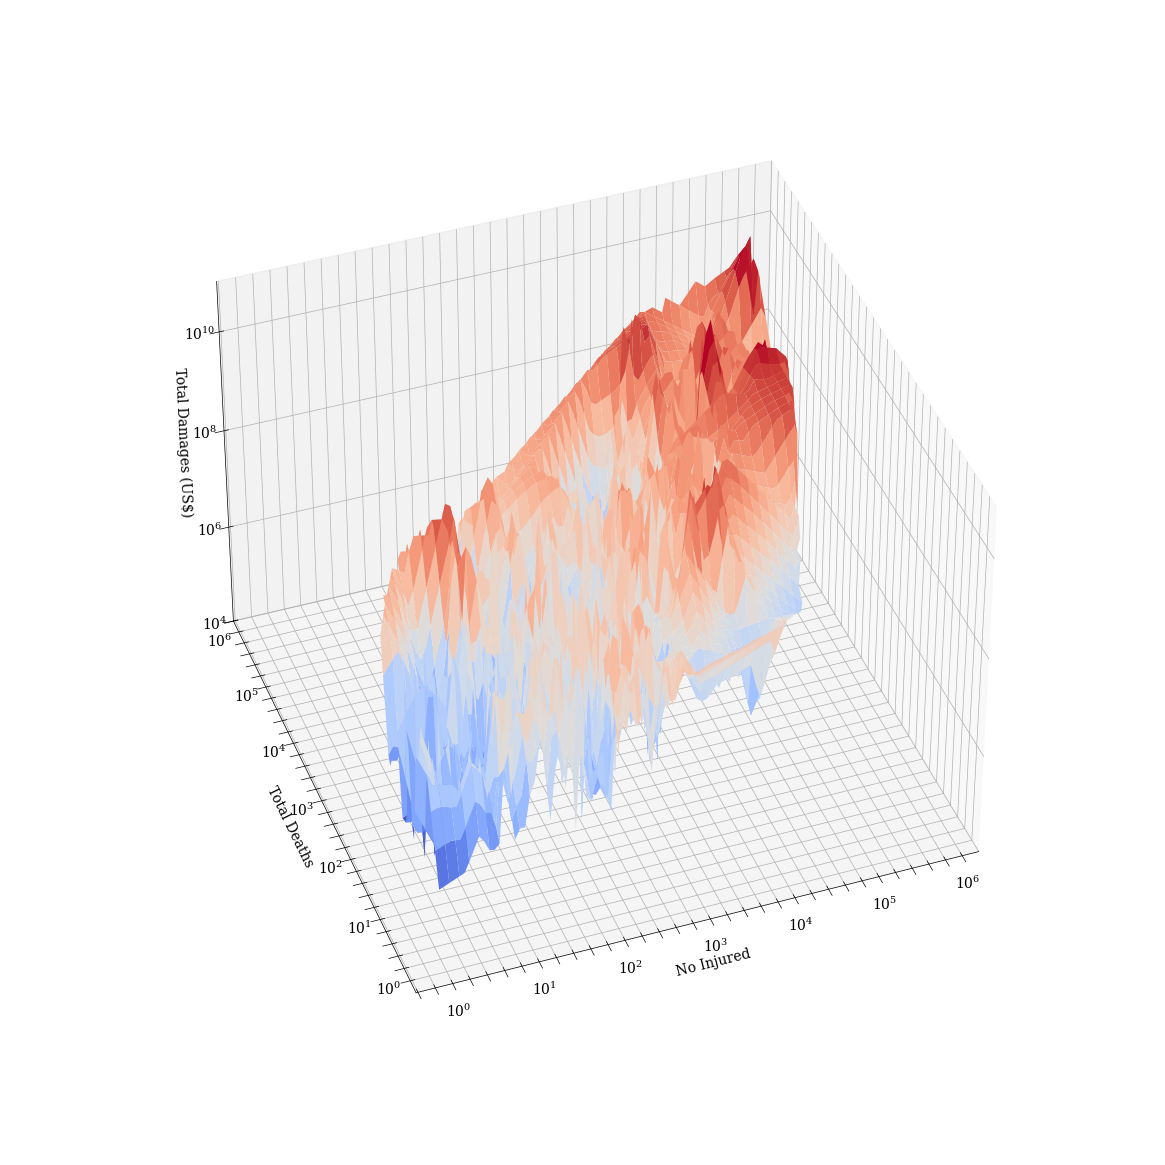

In [7]:
_plot_3D_surface(elev=40, azim=-110, grid_size=100)


# Slide 12

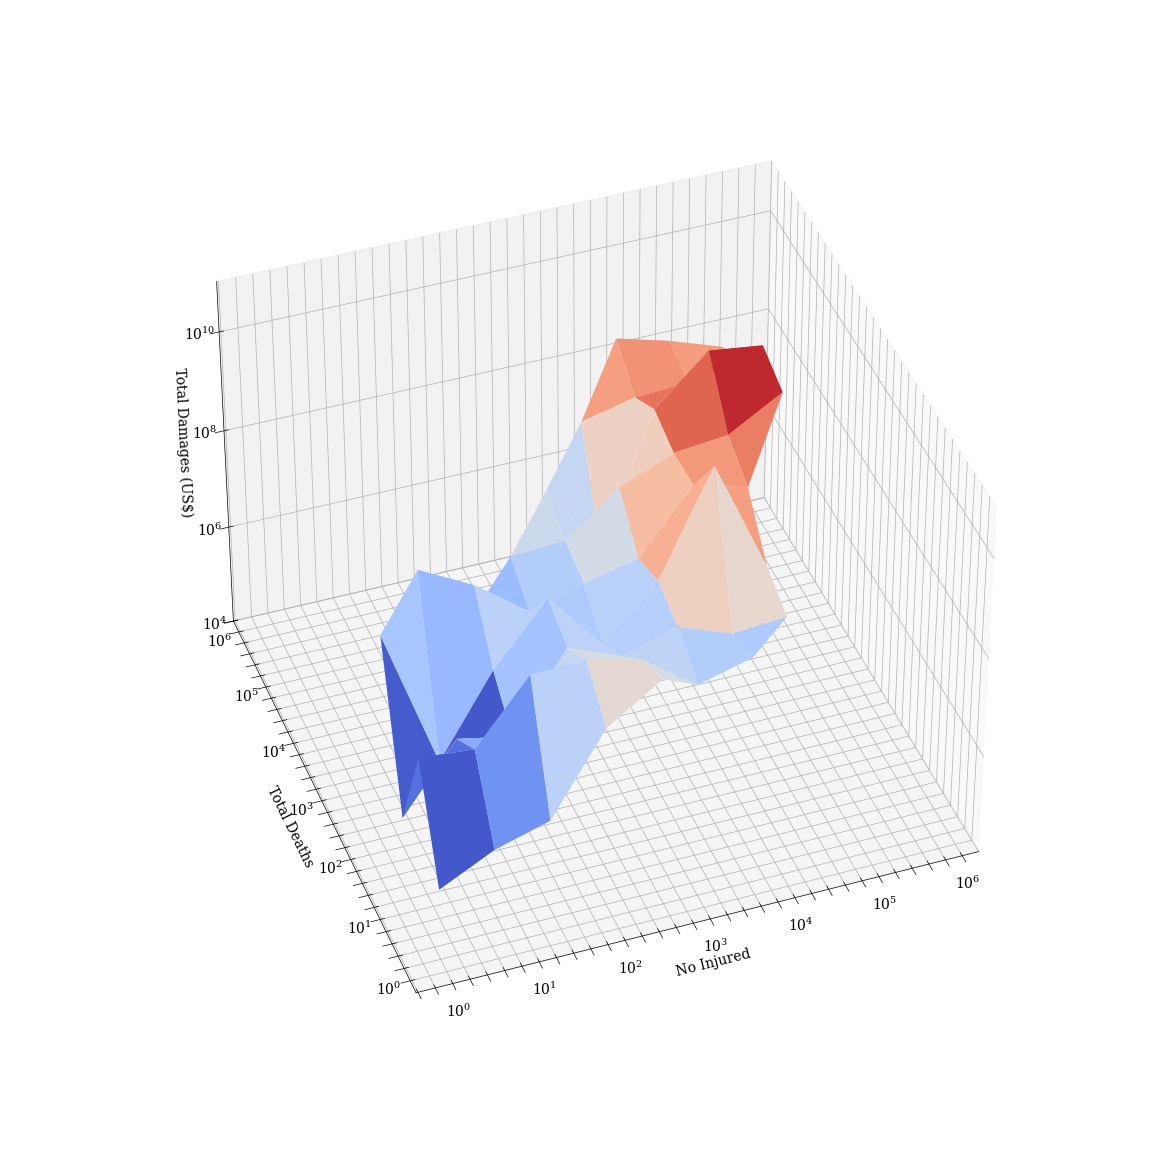

In [8]:
_plot_3D_surface(elev=40, azim=-110, grid_size=10)


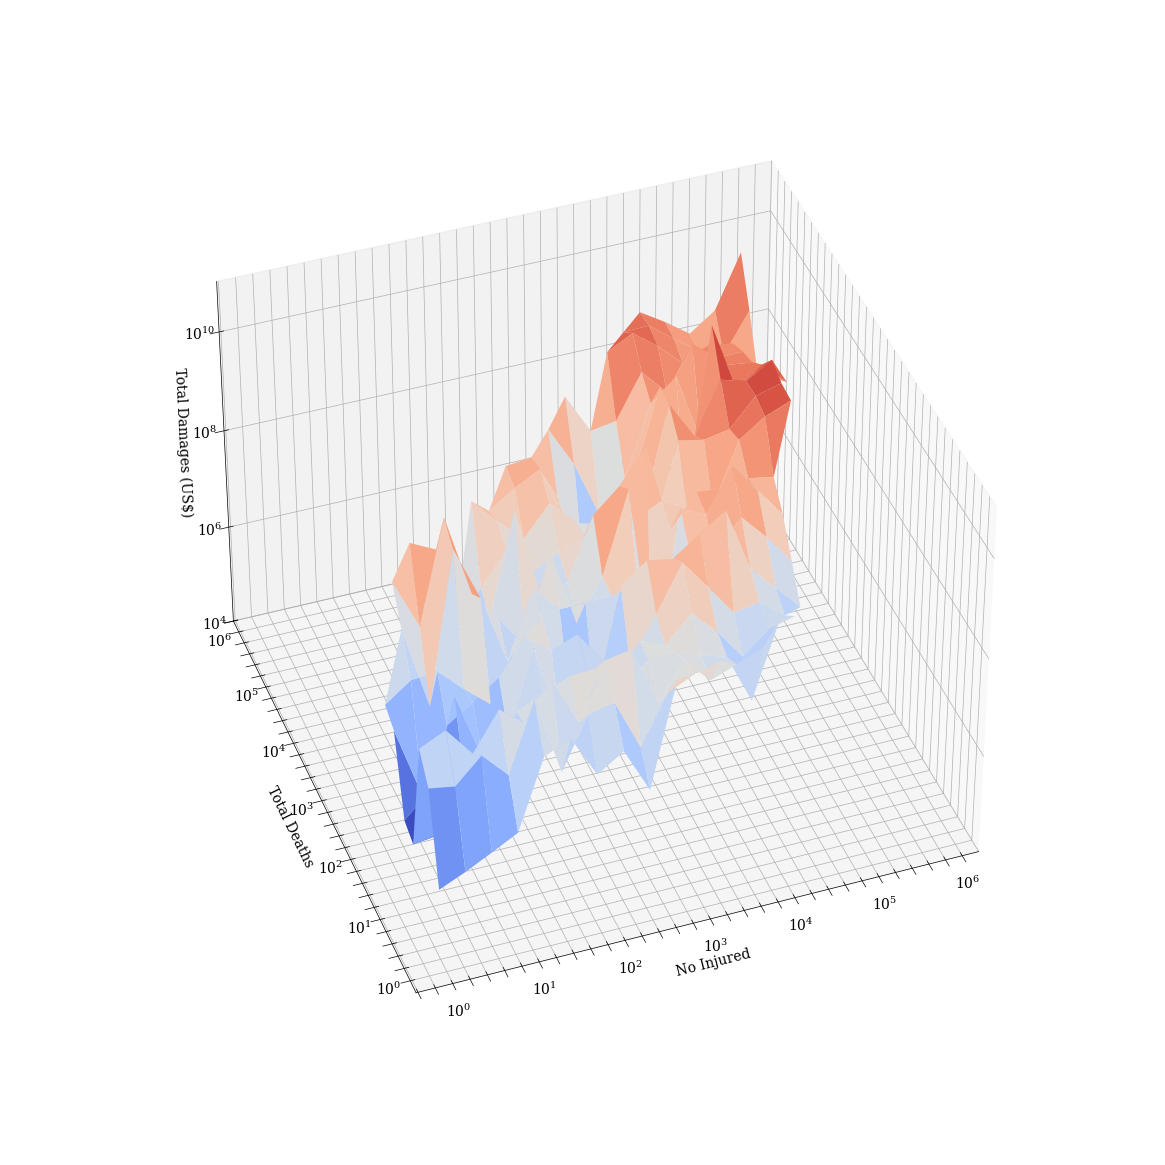

In [9]:
_plot_3D_surface(elev=40, azim=-110, grid_size=20)


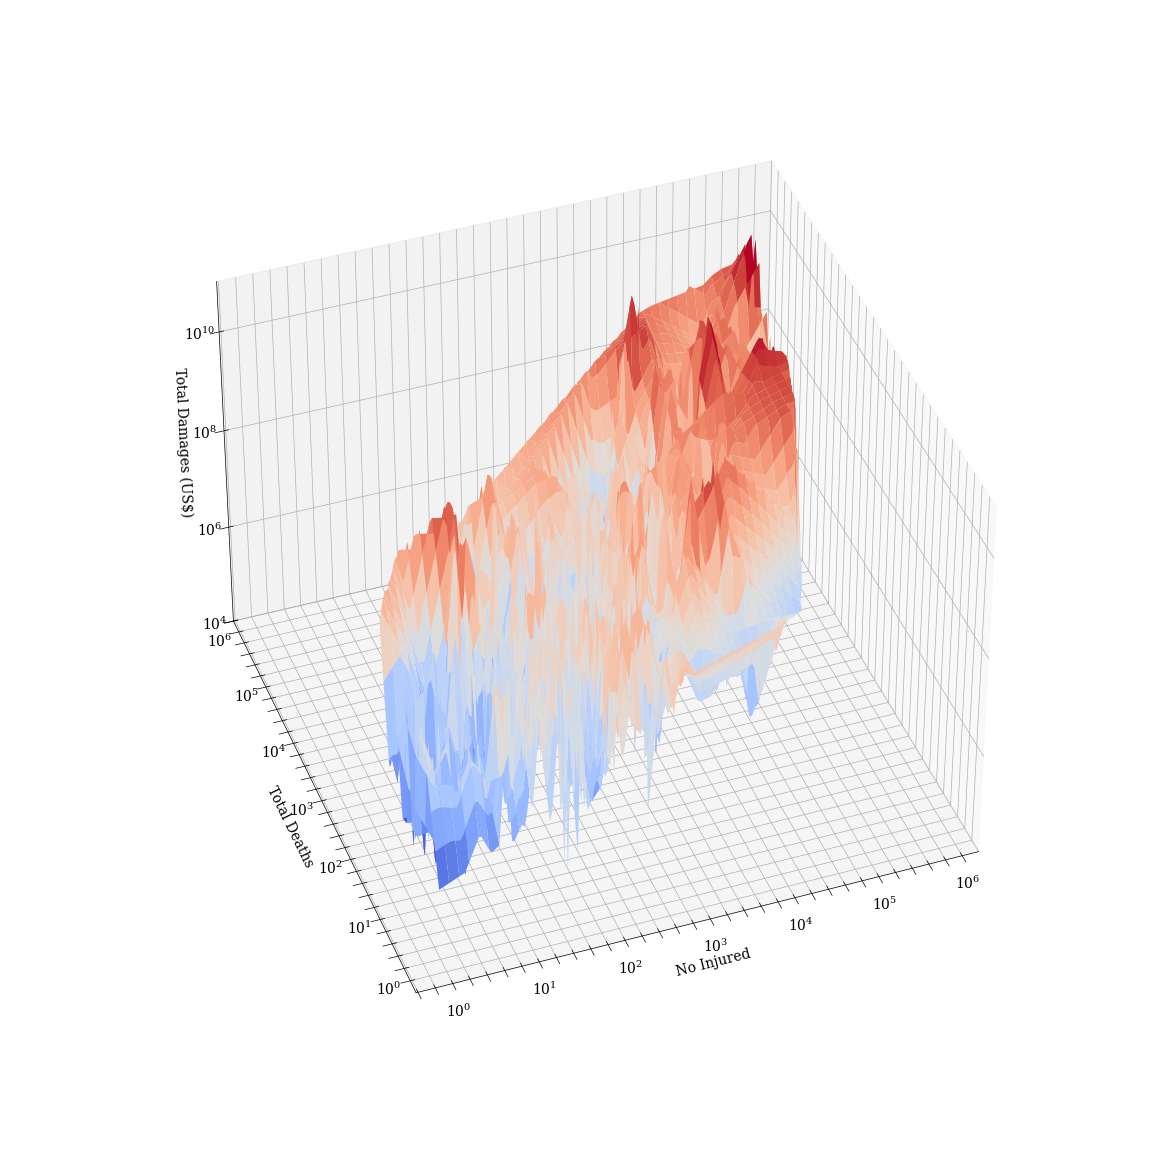

In [10]:
_plot_3D_surface(elev=40, azim=-110, grid_size=200)


# Slide 20 

/sessions/eloquent-amazing-fermat/tmp/ipykernel_13/3892929508.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset["year"] = df_subset["date"].dt.year
/sessions/eloquent-amazing-fermat/tmp/ipykernel_13/3892929508.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset["month"] = df_subset["date"].dt.month


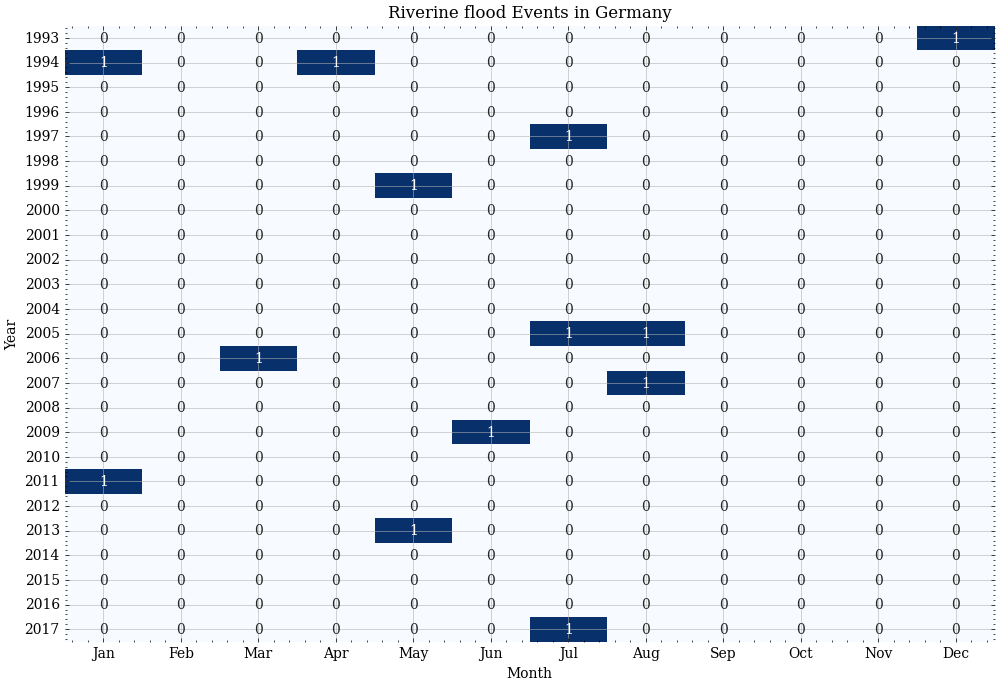

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

country_focus = "Germany"
disaster_event_focus = "Riverine flood"

# group df_subset by year and month and count occurrences
df_subset = df[
    (df["Disaster Subtype"] == disaster_event_focus)
    & (df["Country"] == country_focus)
]
df_subset["year"] = df_subset["date"].dt.year
df_subset["month"] = df_subset["date"].dt.month

# group by year and month, count occurrences, and reset index
df_grouped = df_subset.groupby(["year", "month"]).size().reset_index(name="count")

# make sure all year-month combinations are present
all_years = range(df_grouped["year"].min(), df_grouped["year"].max() + 1)
all_months = range(1, 13)
all_combinations = pd.MultiIndex.from_product(
    [all_years, all_months], names=["year", "month"]
)
df_grouped = (
    df_grouped.set_index(["year", "month"])
    .reindex(all_combinations, fill_value=0)
    .reset_index()
)


plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    df_grouped.pivot(index="year", columns="month", values="count"),
    cmap="Blues",
    annot=True,
)
plt.title(f"{disaster_event_focus} Events in {country_focus}")
# remove the colorbar
cb = ax.collections[0].colorbar
cb.remove()

# label x ticks with month names
month_names = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
ax.set_xticklabels(month_names)

plt.xlabel("Month")
plt.ylabel("Year")
plt.savefig(figpath(f'heatmap_{disaster_event_focus}_{country_focus}.pdf'), bbox_inches='tight')
plt.show()

# Slide 23

MAE: 0.861279520465127, MSE: 1.1397927412374464, RMSE: 1.067610762983142


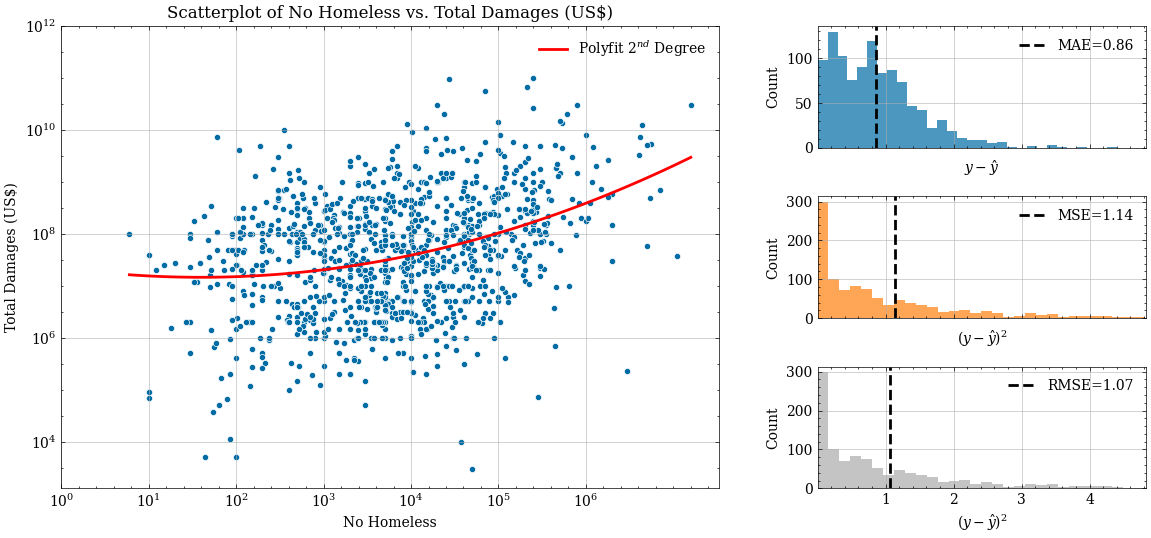

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

def _plot_scatter_with_error_histograms(df, x_axis, y_axis, fit_polyfit):
    mask = (df[x_axis] > 0) & (df[y_axis] > 0)
    x = np.log10(df.loc[mask, x_axis])
    y = np.log10(df.loc[mask, y_axis])

    fig = plt.figure()
    gs = fig.add_gridspec(3, 2, width_ratios=[2, 1], hspace=0.4)

    # Scatter and fitted poly
    ax_scatter = fig.add_subplot(gs[:, 0])
    ax_scatter.scatter(x, y, s=20, marker='o', alpha=1, edgecolors='w', linewidth=0.5)
    if fit_polyfit:
        n = 2
        coefficients = np.polyfit(x, y, n)
        poly = np.poly1d(coefficients)
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = poly(x_fit)
        ax_scatter.plot(x_fit, y_fit, color='red', linewidth=2, label=f'Polyfit ${n}^{{nd}}$ Degree')
        y_pred = poly(x)
        residuals = y - y_pred
        mae = np.abs(residuals)
        mse = residuals**2
        rmse = mse
        
        sk_mae = mean_absolute_error(y, y_pred)
        sk_mse = mean_squared_error(y, y_pred)
        sk_rmse = root_mean_squared_error(y, y_pred)
        print(f"MAE: {sk_mae}, MSE: {sk_mse}, RMSE: {sk_rmse}")
    else:
        mae = mse = rmse = np.zeros_like(y)

    ax_scatter.set_xticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]))
    ax_scatter.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$', '$10^4$', '$10^5$', '$10^6$'])
    ax_scatter.set_yticks(np.log10([1e4, 1e6, 1e8, 1e10, 1e12]))
    ax_scatter.set_yticklabels(['$10^4$', '$10^6$', '$10^8$', '$10^{10}$', '$10^{12}$'])
    ax_scatter.legend()
    ax_scatter.set_xlabel(f'{x_axis}')
    ax_scatter.set_ylabel(f'{y_axis}')
    ax_scatter.set_title(f'Scatterplot of {x_axis} vs. {y_axis}')

    # Histograms stacked vertically, sharing x-axis
    metrics = [mae, mse, rmse]
    titles = ['MAE', 'MSE', 'RMSE']
    defined_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]


    # Find global min/max for x-axis
    all_errors = np.concatenate(metrics)
    x_min, x_max = all_errors.min(), all_errors.max() * 0.25

    for i, (err, title, color) in enumerate(zip(metrics, titles, defined_colors)):
        ax = fig.add_subplot(gs[i, 1])
        visual_err = err[(err > x_min) & (err < x_max)]
        ax.hist(visual_err, bins=30, alpha=0.7, color=color)
        metric_value = err.mean()
        if title == 'RMSE':
            metric_value = np.sqrt(np.mean(err))
        ax.axvline(metric_value, color='k', linestyle='dashed', linewidth=2, label=f"{title}={metric_value:.2f}")
        ax.set_xlim(x_min, x_max)
        if i == 0: 
            ax.set_xlabel('$y - \hat{y}$')
        else: 
            ax.set_xlabel('$(y - \hat{y})^2$')
        ax.set_ylabel('Count')
        ax.legend()
        if i < 2:
            ax.tick_params(labelbottom=False)

    plt.savefig(figpath(f'scatter_histogram_{x_axis}_{y_axis}_fit{fit_polyfit}.pdf'), bbox_inches='tight')
    plt.show()

_plot_scatter_with_error_histograms(df, x_axis='No Homeless', y_axis='Total Damages (US$)', fit_polyfit=True)

# Slide 24

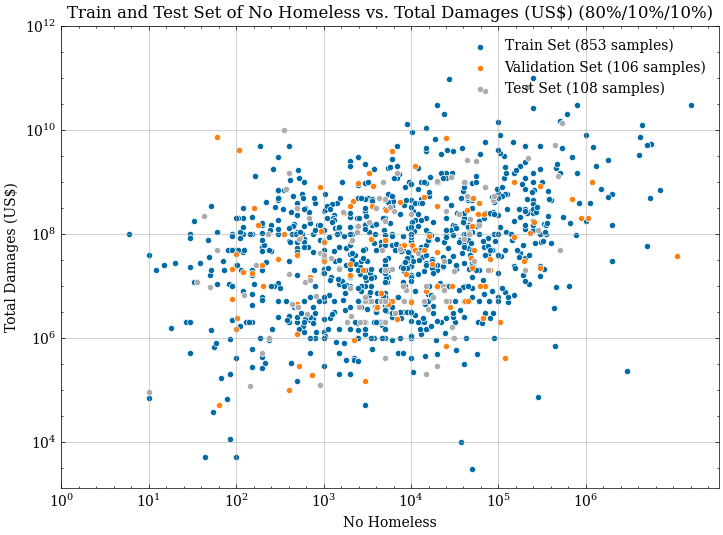

In [13]:
def _plot_scatter_with_train_test_split(df, x_axis='No Homeless', y_axis='Total Damages (US$)', train_ratio=0.8, val_ratio=0.1):
    mask = (df[x_axis] > 0) & (df[y_axis] > 0)
    x = np.log10(df.loc[mask, x_axis])
    y = np.log10(df.loc[mask, y_axis])
    test_ratio = 1 - train_ratio - val_ratio

    np.random.seed(0)
    indices = np.random.permutation(len(x))
    train_size = int(len(x) * train_ratio)
    val_size = int(len(x) * val_ratio)
    test_size = len(x) - train_size - val_size

    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size + val_size]
    test_indices = indices[train_size + val_size:]

    x_train = x.iloc[train_indices]
    y_train = y.iloc[train_indices]
    x_val = x.iloc[val_indices]
    y_val = y.iloc[val_indices]
    x_test = x.iloc[test_indices]
    y_test = y.iloc[test_indices]

    fig = plt.figure()
    gs = fig.add_gridspec(3, 2, width_ratios=[2, 1], hspace=0.4)

    # Scatter and fitted poly
    ax_scatter = fig.add_subplot(gs[:, 0])
    ax_scatter.scatter(x_train, y_train, s=20, marker='o', alpha=1, edgecolors='w', linewidth=0.5, label=f'Train Set ({x_train.shape[0]} samples)')
    ax_scatter.scatter(x_val, y_val, s=20, marker='o', alpha=1, edgecolors='w', linewidth=0.5, label=f'Validation Set ({x_val.shape[0]} samples)')
    ax_scatter.scatter(x_test, y_test, s=20, marker='o', alpha=1, edgecolors='w', linewidth=0.5, label=f'Test Set ({x_test.shape[0]} samples)')
    ax_scatter.set_xticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]))
    ax_scatter.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$', '$10^4$', '$10^5$', '$10^6$'])
    ax_scatter.set_yticks(np.log10([1e4, 1e6, 1e8, 1e10, 1e12]))
    ax_scatter.set_yticklabels(['$10^4$', '$10^6$', '$10^8$', '$10^{10}$', '$10^{12}$'])
    ax_scatter.legend(loc='upper right', bbox_to_anchor=(1.0, 1))
    ax_scatter.set_xlabel(f'{x_axis}')
    ax_scatter.set_ylabel(f'{y_axis}')
    ax_scatter.set_title(f'Train and Test Set of {x_axis} vs. {y_axis} ({train_ratio*100:.0f}%/{(val_ratio)*100:.0f}%/{(test_ratio)*100:.0f}%)')
    plt.savefig(figpath(f'scatter_train_test_split_{x_axis}_{y_axis}_train{train_ratio}_val{val_ratio}.pdf'), bbox_inches='tight')
    plt.show()
    
_plot_scatter_with_train_test_split(df, x_axis='No Homeless', y_axis='Total Damages (US$)', train_ratio=0.8, val_ratio=0.1)


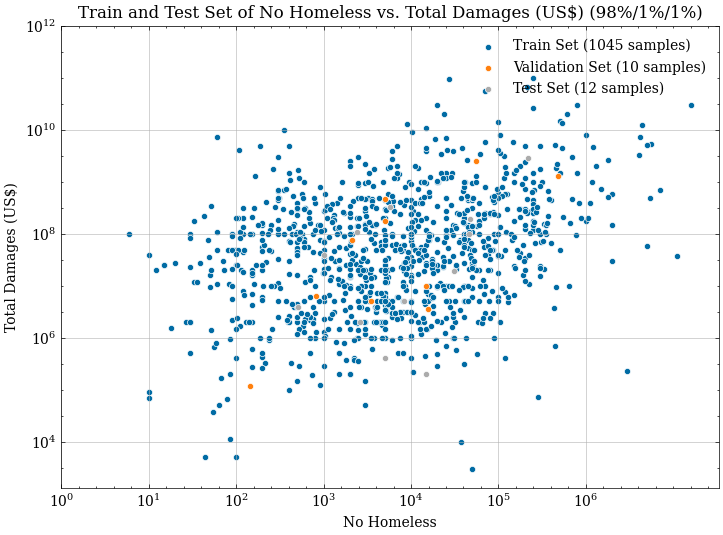

In [14]:
_plot_scatter_with_train_test_split(df, x_axis='No Homeless', y_axis='Total Damages (US$)', train_ratio=0.98, val_ratio=0.01)


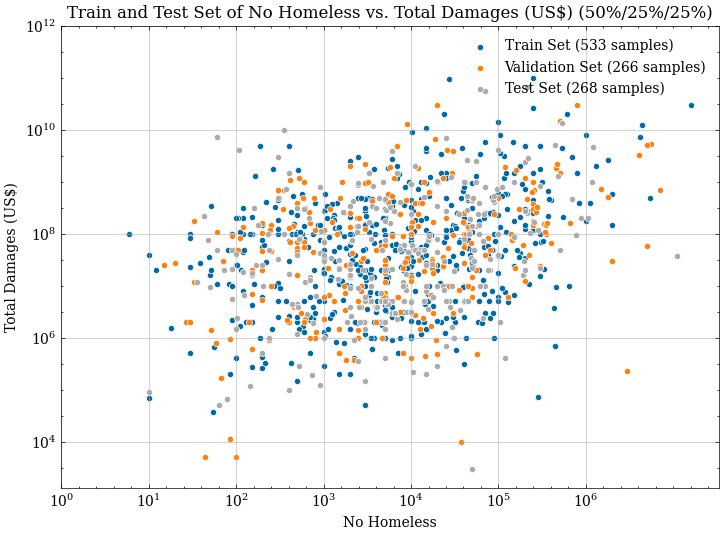

In [15]:
_plot_scatter_with_train_test_split(df, x_axis='No Homeless', y_axis='Total Damages (US$)', train_ratio=0.5, val_ratio=0.25)


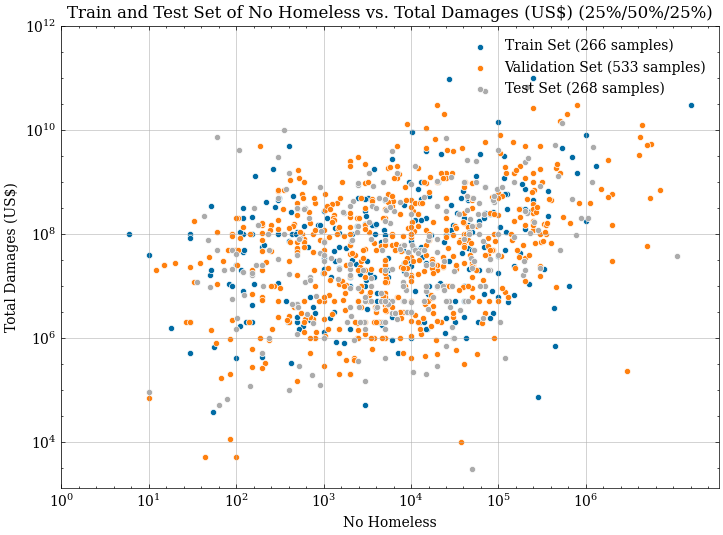

In [16]:
_plot_scatter_with_train_test_split(df, x_axis='No Homeless', y_axis='Total Damages (US$)', train_ratio=0.25, val_ratio=0.5)


# Slide 33

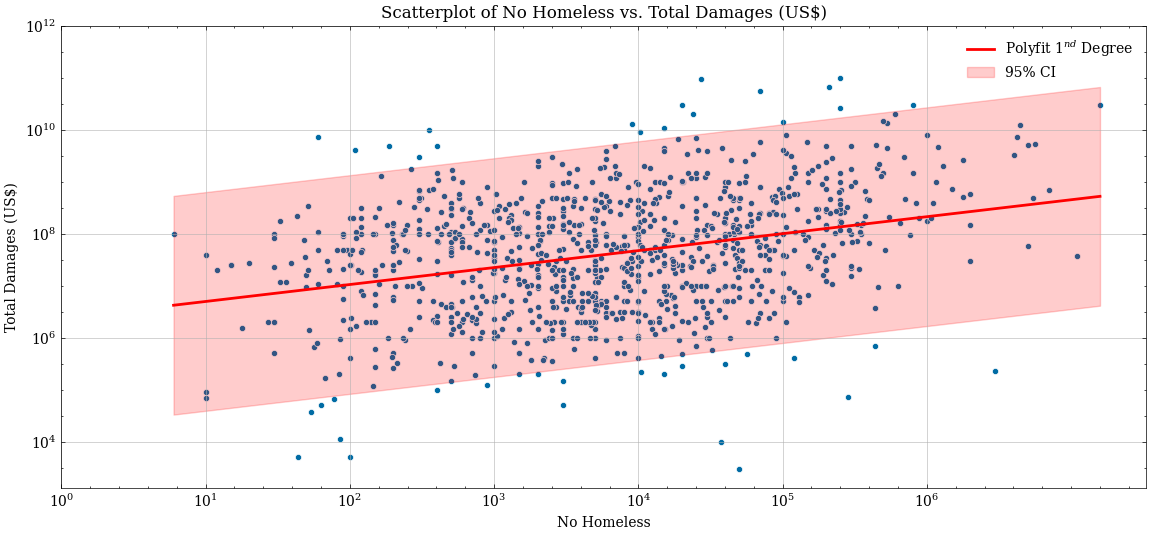

In [17]:
def _plot_scatter_confidence(df, x_axis, y_axis, fit_polyfit, n=1, conf_alpha=0.2):
    mask = (df[x_axis] > 0) & (df[y_axis] > 0)
    x = np.log10(df.loc[mask, x_axis])
    y = np.log10(df.loc[mask, y_axis])

    plt.scatter(x, y, s=20, marker='o', alpha=1, edgecolors='w', linewidth=0.5)

    if fit_polyfit:
        coefficients = np.polyfit(x, y, n)
        poly = np.poly1d(coefficients)
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = poly(x_fit)

        # Calculate confidence interval (approximate, using residual std)
        y_pred = poly(x)
        residuals = y - y_pred
        std_err = residuals.std()
        # 95% confidence interval (approximate, not accounting for leverage)
        ci = 1.96 * std_err

        plt.plot(x_fit, y_fit, color='red', linewidth=2, label=f'Polyfit ${n}^{{nd}}$ Degree')
        plt.fill_between(x_fit, y_fit - ci, y_fit + ci, color='red', alpha=conf_alpha, label='95% CI')

    plt.xticks(ticks=np.log10([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]), labels=['$10^0$', '$10^1$', '$10^2$', '$10^3$', '$10^4$', '$10^5$', '$10^6$'])
    plt.yticks(ticks=np.log10([1e4, 1e6, 1e8, 1e10, 1e12]), labels=['$10^4$', '$10^6$', '$10^8$', '$10^{10}$', '$10^{12}$'])
    plt.legend()
    plt.xlabel(f'{x_axis}')
    plt.ylabel(f'{y_axis}')
    plt.title(f'Scatterplot of {x_axis} vs. {y_axis}')
    plt.savefig(figpath(f'scatter_confidence_{x_axis}_{y_axis}_fit{n}.pdf'), bbox_inches='tight')
    plt.show()

x_axis = 'No Homeless'
y_axis = 'Total Damages (US$)'
fit_polyfit = True
_plot_scatter_confidence(df, x_axis, y_axis, fit_polyfit, n=1)

# Slide 36

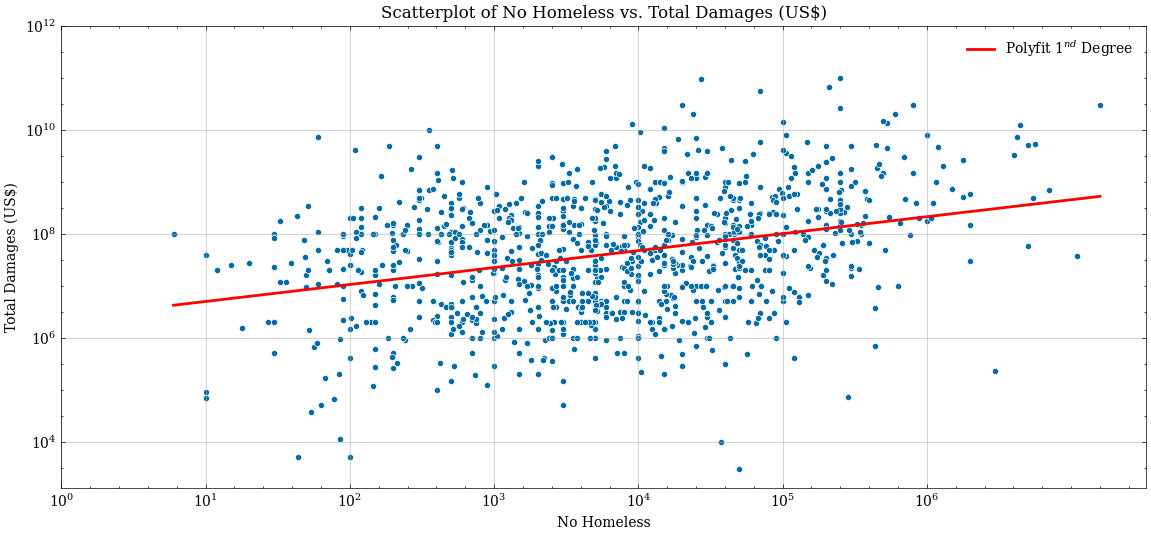

In [18]:
x_axis = 'No Homeless'
y_axis = 'Total Damages (US$)'
fit_polyfit = True

_plot_scatter(df, x_axis, y_axis, fit_polyfit, n=1)

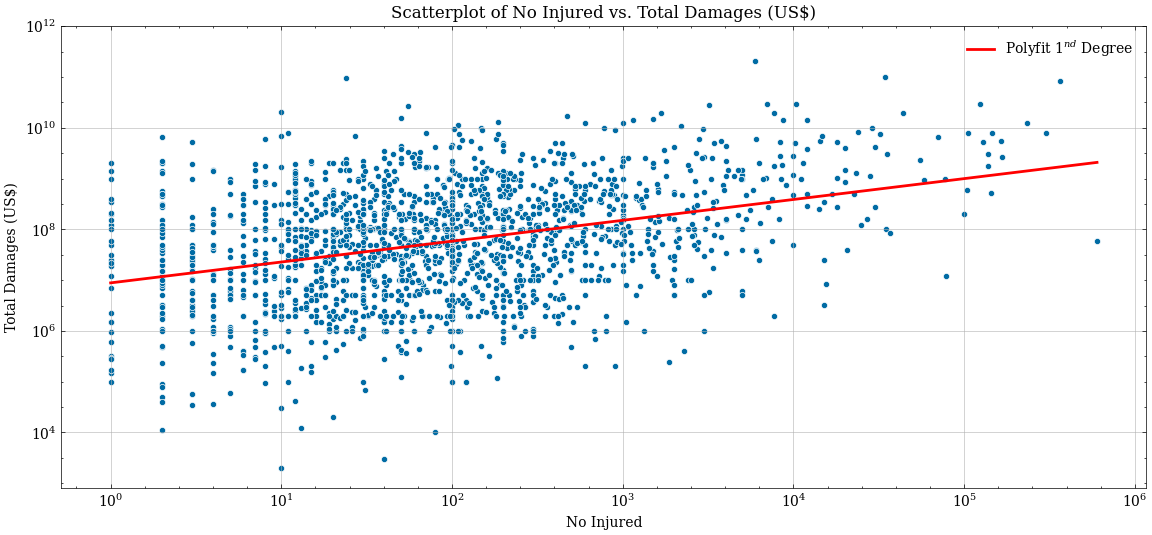

In [19]:
x_axis = 'No Injured'
y_axis = 'Total Damages (US$)'
fit_polyfit = True

_plot_scatter(df, x_axis, y_axis, fit_polyfit, n=1)

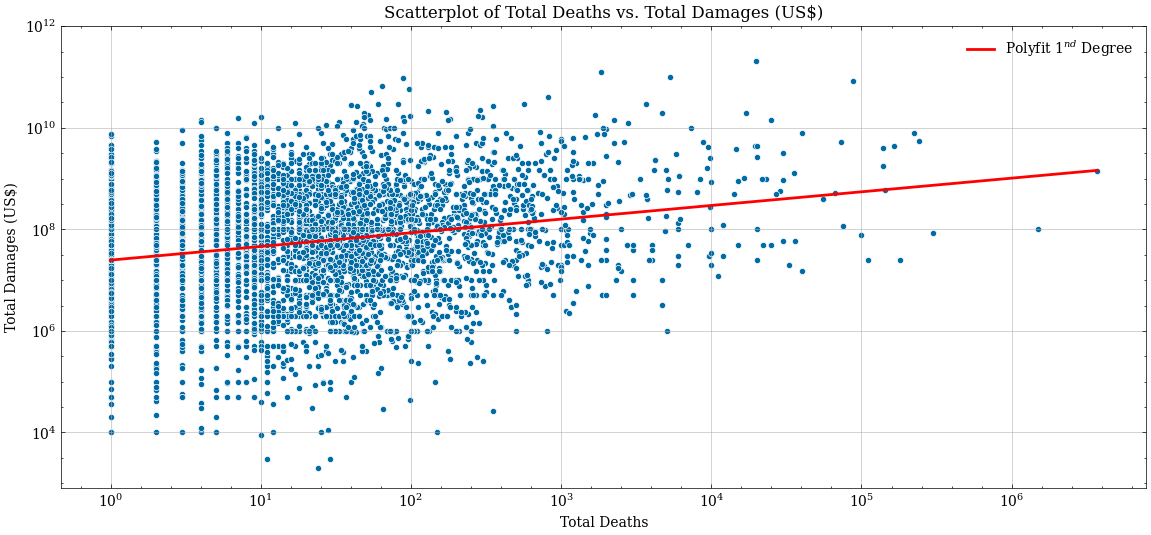

In [20]:
x_axis = 'Total Deaths'
y_axis = 'Total Damages (US$)'
fit_polyfit = True

_plot_scatter(df, x_axis, y_axis, fit_polyfit, n=1)